In [1]:
import sys
sys.path.append("../")

import importlib
from functools import partial

import matplotlib.pyplot as plt
import numpy as np  
from IPython.display import display
import pandas as pd 

import torch
import torch.nn.functional as F
from torch_geometric.loader import DataLoader
from torch_geometric.utils import from_networkx

In [2]:
# Reproducibility
SEED = 123123
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = True 
np.random.seed(SEED)

In [3]:
DATASET_NAME = "NCI1"

In [4]:
config = {
    "DATASET_NAME": DATASET_NAME, 
    "device": "cuda",
    "explainee": {
        "epochs": 100, 
        "batch_size": 16, 
        "lr": 1e-3
    }, 
    "ged_model": {
        "n_perds": 1, 
        "epochs": 25, 
        "batch_size": 16, 
    }, 
    "tune": {
        "n_trials": 8, 
        "max_nodes": 24, 
        "iters_per_sample": 16, 
        "samples_per_trial": 8, # Note: per class. 
    },
    "train": {
        "iters_per_sample": 200, 
        "samples_per_trial": 25, # Note: per class. 
    }
}

# Data

In [5]:
import new_src.dataAdapter
from new_src.dataAdapter import load_dataset
importlib.reload(new_src.dataAdapter)

data = load_dataset(config.get("DATASET_NAME"))
cls_split = data.split_by_class()

# Explainee

In [6]:
import new_src.explainee
from new_src.explainee import fit_explainee
importlib.reload(new_src.explainee)

explainee, _ = fit_explainee(
    dataset_name = config.get("DATASET_NAME"),
    root="data",
    hidden=64,
    layers=3,
    dropout=0.2,
    epochs=config["explainee"]["epochs"],
    batch_size=config["explainee"]["batch_size"],
    lr=config["explainee"]["lr"],
    device=config.get("device")
)


# Extract embeddings. 
mean_embeds = [
    torch.cat([explainee(batch.to(config.get("device")))["embeds"]
               for batch in DataLoader(subset, batch_size=64)])
         .mean(dim=0)
    for subset in cls_split
]
mean_embeds = [m.detach() for m in mean_embeds]

[001/100] train_loss=0.6689  val_acc=0.613
[002/100] train_loss=0.6298  val_acc=0.659
[003/100] train_loss=0.6089  val_acc=0.652
[004/100] train_loss=0.6002  val_acc=0.650
[005/100] train_loss=0.5918  val_acc=0.664
[006/100] train_loss=0.5882  val_acc=0.684
[007/100] train_loss=0.5680  val_acc=0.693
[008/100] train_loss=0.5706  val_acc=0.693
[009/100] train_loss=0.5654  val_acc=0.689
[010/100] train_loss=0.5646  val_acc=0.689
[011/100] train_loss=0.5667  val_acc=0.703
[012/100] train_loss=0.5572  val_acc=0.696
[013/100] train_loss=0.5570  val_acc=0.664
[014/100] train_loss=0.5511  val_acc=0.672
[015/100] train_loss=0.5500  val_acc=0.684
[016/100] train_loss=0.5421  val_acc=0.691
[017/100] train_loss=0.5490  val_acc=0.681
[018/100] train_loss=0.5434  val_acc=0.684
[019/100] train_loss=0.5470  val_acc=0.686
[020/100] train_loss=0.5458  val_acc=0.691
[021/100] train_loss=0.5469  val_acc=0.681
[022/100] train_loss=0.5468  val_acc=0.667
[023/100] train_loss=0.5376  val_acc=0.696
[024/100] t

# GED Approximator

Generating synthetic GED dataset with 1 perturbations per graph...
Created GED dataset with 4110 pairs.


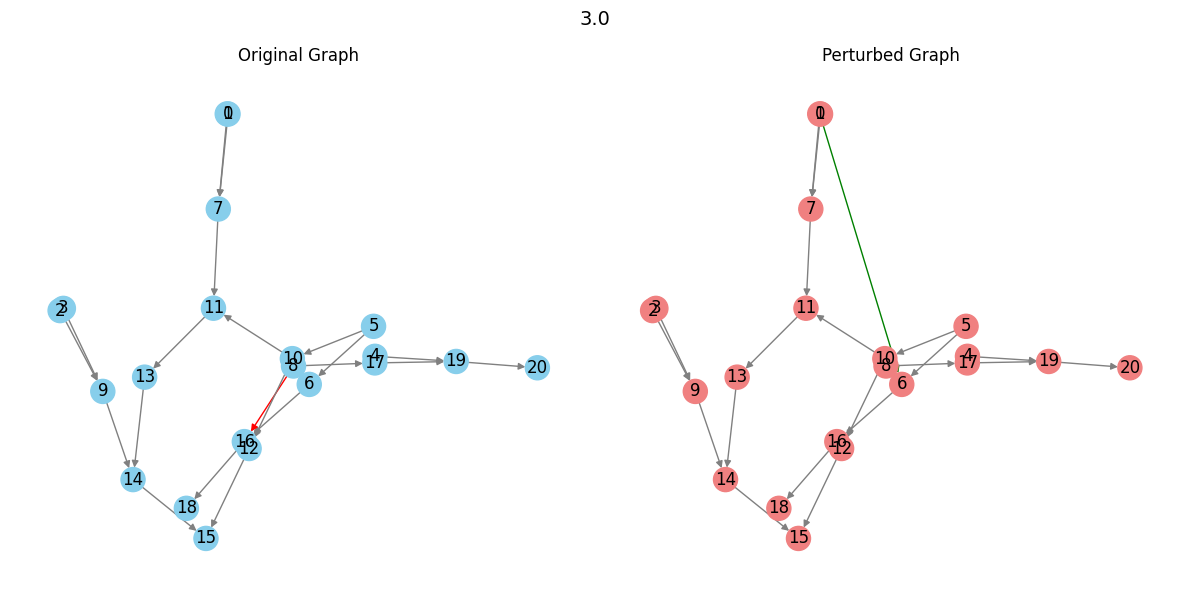

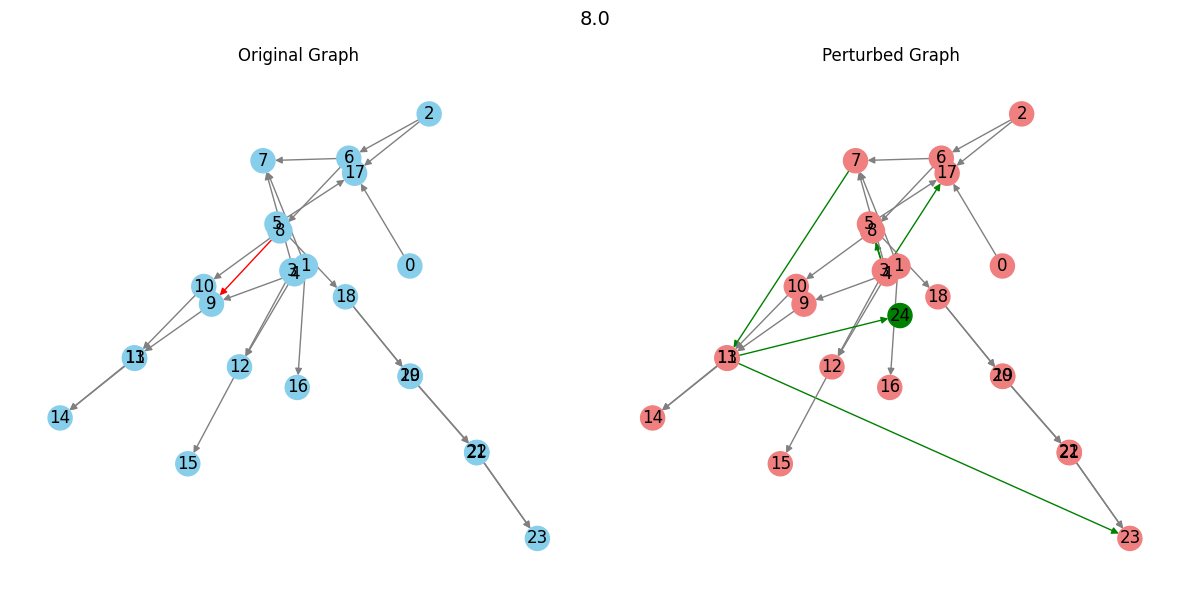

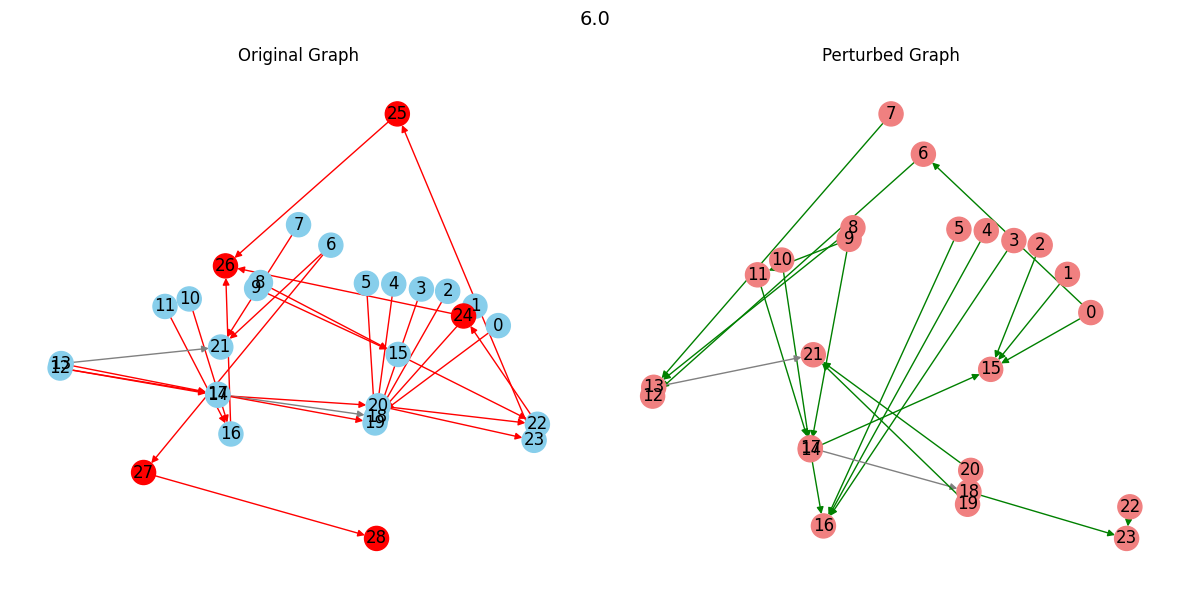

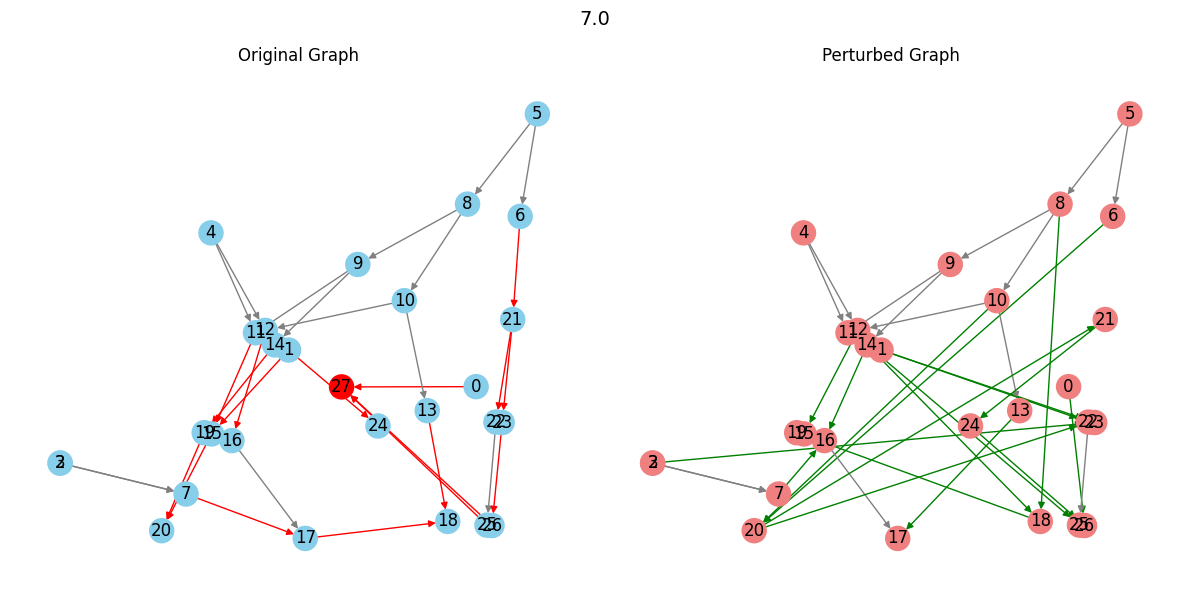

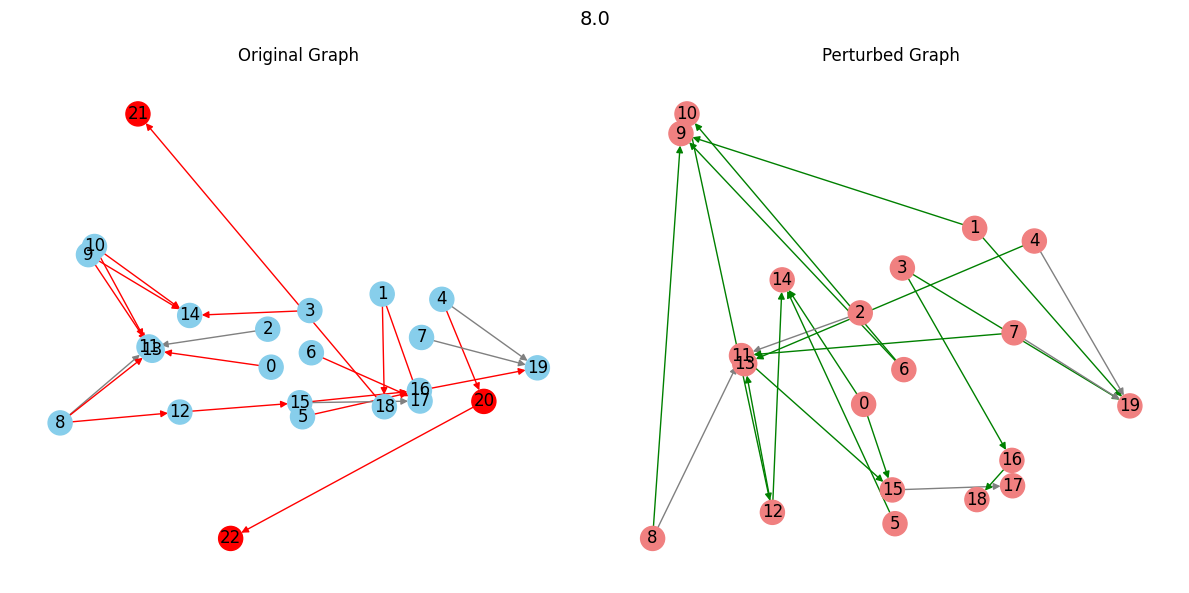

In [7]:
import new_src.ged_dataset
importlib.reload(new_src.ged_dataset)

from new_src.ged_dataset import create_and_save_ged_dataset, plot_graph_pair

ged_dataset = create_and_save_ged_dataset(
    data, 
    out_path=None, 
    n_perturbations=config["ged_model"]["n_perds"],
    node_add_prob=0.5,
    node_remove_prob=0.5,
    edge_add_prob=0.1, 
    edge_remove_prob=0.1
)

print(f"Created GED dataset with {len(ged_dataset)} pairs.")

for i in range(5):
    g1, g2, ged_norm, _, _ = ged_dataset[i]
    raw_ged = getattr(g1, "raw_ged", ged_norm)
    plot_graph_pair(g1, g2, label=raw_ged)

In [8]:
import new_src.simgnn
importlib.reload(new_src.simgnn)

from new_src.simgnn import SimGNN, train_simgnn

model = SimGNN(in_dim=len(data.NODE_CLS))

train_simgnn(
    model=(m := model), 
    data=ged_dataset, 
    batch_size=config["ged_model"]["batch_size"], 
    optimizer=(o := torch.optim.Adam(m.parameters(), lr=1e-3)),
    scheduler=torch.optim.lr_scheduler.ExponentialLR(o, gamma=1),
    epochs=config["ged_model"]["epochs"], 
    device=config.get("device")
)

Training SimGNN:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 001 | Loss: 0.2300 | MSE(norm): 0.2300 | MSE(raw): 641.1348 | Corr(norm): 0.1917 | Corr(raw): 0.6521
Epoch 002 | Loss: 0.1292 | MSE(norm): 0.1292 | MSE(raw): 283.1100 | Corr(norm): 0.4868 | Corr(raw): 0.8124
Epoch 003 | Loss: 0.1248 | MSE(norm): 0.1248 | MSE(raw): 316.3619 | Corr(norm): 0.5416 | Corr(raw): 0.8098
Epoch 004 | Loss: 0.0942 | MSE(norm): 0.0942 | MSE(raw): 200.1122 | Corr(norm): 0.6548 | Corr(raw): 0.8728
Epoch 005 | Loss: 0.0798 | MSE(norm): 0.0798 | MSE(raw): 165.3268 | Corr(norm): 0.7180 | Corr(raw): 0.8968
Epoch 006 | Loss: 0.0735 | MSE(norm): 0.0735 | MSE(raw): 148.7474 | Corr(norm): 0.7433 | Corr(raw): 0.9055
Epoch 007 | Loss: 0.0740 | MSE(norm): 0.0740 | MSE(raw): 152.9390 | Corr(norm): 0.7414 | Corr(raw): 0.9032
Epoch 008 | Loss: 0.0725 | MSE(norm): 0.0725 | MSE(raw): 155.4829 | Corr(norm): 0.7466 | Corr(raw): 0.9000
Epoch 009 | Loss: 0.0648 | MSE(norm): 0.0648 | MSE(raw): 110.1826 | Corr(norm): 0.7782 | Corr(raw): 0.9292
Epoch 010 | Loss: 0.0626 | MSE(norm):

# Generator

In [ ]:
# All passes should be explicit. 
def train_generator(
    cls_idx, 
    max_nodes, 
    iters_per_sample, 
    data, 
    mean_embeds, 
    explainee, 
    ged_model, 
    w_pred=1,
    w_embed=1,
    w_ged=1,
    w_mcs=1,
    w_spec=1,
    w_wl=1,
    use_omega=False,  
):

    from new_src.graph_sampler import GraphSampler
    from new_src.trainer import Trainer
    from new_src.criteria import (
        WeightedCriterion, 
        ClassScoreCriterion, 
        EmbeddingCriterion, 
        BudgetPenalty
    )
    
    from new_src.graph_level_dist import (
        neural_approx_ged_dist, 
        mcs_soft_graph_dist, 
        spectral_dist, 
        wl_graph_kernel_dist
    )
    
    trainer = Trainer(
        sampler=(
            s := GraphSampler(
                    max_nodes=max_nodes,
                    num_node_cls=len(data.NODE_CLS),
                    num_edge_cls=len(data.EDGE_CLS), 
                    temperature=0.15,
                    learn_node_feat=len(data.NODE_CLS) > 0, 
                    learn_edge_feat=len(data.EDGE_CLS) > 0, 
            )
        ),
        discriminator=explainee,
        criterion=WeightedCriterion([
            dict(key="logits", 
                criterion=ClassScoreCriterion(
                    class_idx=cls_idx, mode='maximize'
                ), 
                weight=w_pred
            ),
            dict(key="embeds", 
                criterion=EmbeddingCriterion(
                    target_embedding=mean_embeds[cls_idx]
                ), 
                weight=w_embed
            ),
            dict(key="cont_data", 
                criterion=neural_approx_ged_dist(
                    data = data, model = ged_model, explainee=explainee, 
                    cls_idx=cls_idx, 
                    use_omega=use_omega
                ), 
                weight=w_ged
            ), 
            dict(key="cont_data", 
                criterion=mcs_soft_graph_dist(
                    data = data, explainee=explainee, 
                    cls_idx=cls_idx, 
                    use_omega=use_omega
                ), 
                weight=w_mcs
            ), 
            dict(key="cont_data", 
                criterion=spectral_dist(
                    data = data, explainee=explainee, 
                    cls_idx=cls_idx, 
                    use_omega=use_omega
                ), 
                weight=w_spec
            ), 
            dict(key="cont_data", 
                criterion=wl_graph_kernel_dist(
                    data = data, explainee=explainee, 
                    cls_idx=cls_idx, 
                    use_omega=use_omega
                ), 
                weight=w_wl
            ), 
        ]),
        optimizer=(o := torch.optim.SGD(s.parameters(), lr=1)),
        scheduler=torch.optim.lr_scheduler.ExponentialLR(o, gamma=1),
        dataset=data,
        budget_penalty=BudgetPenalty(budget=20, order=2, beta=1),
        device=config.get("device")
    )

    trainer.train(
        iterations=iters_per_sample,
        target_probs={cls_idx: (0.9, 1.0)},
        target_size=30,
        w_budget_init=0.5,
        w_budget_inc=1.1,
        w_budget_dec=0.95,
        k_samples=32
    )

    example = trainer.evaluate(threshold=0.5)

    example = from_networkx(example)

    if "label" in example: 
        example.x = F.one_hot(
            example.label, num_classes=len(data.NODE_CLS)
        ).float()

    if "edge_label" in example: 
        example.edge_attr = F.one_hot(
            example.edge_label, num_classes=len(data.EDGE_CLS)
        ).float()

    example.y = torch.tensor(cls_idx).float()
    
    return example

: 

## Tuning

In [ ]:
import ray
from ray import tune
from ray import air
from ray.tune import ExperimentAnalysis
ray.shutdown()
ray.init(
    runtime_env={
        "py_modules": ["/repo/revisions/new_src"]
    },
    num_gpus=1
)

data_ref = ray.put(data)
mean_embeds_ref = ray.put(mean_embeds)
cls_split_ref = ray.put(data.split_by_class())

2025-11-13 17:13:49,650	WARNING services.py:2155 -- WARNING: The object store is using /tmp instead of /dev/shm because /dev/shm has only 67104768 bytes available. This will harm performance! You may be able to free up space by deleting files in /dev/shm. If you are inside a Docker container, you can increase /dev/shm size by passing '--shm-size=10.24gb' to 'docker run' (or add it to the run_options list in a Ray cluster config). Make sure to set this to more than 30% of available RAM.
2025-11-13 17:13:49,879	INFO worker.py:2012 -- Started a local Ray instance.
2025-11-13 17:13:50,172	INFO packaging.py:588 -- Creating a file package for local module '/repo/revisions/new_src'.
2025-11-13 17:13:50,632	INFO packaging.py:380 -- Pushing file package 'gcs://_ray_pkg_86b016a8d266f616.zip' (0.39MiB) to Ray cluster...
2025-11-13 17:13:50,635	INFO packaging.py:393 -- Successfully pushed file package 'gcs://_ray_pkg_86b016a8d266f616.zip'.
/opt/venv/lib/python3.12/site-packages/ray/_private/worker

In [ ]:
def tune_generator(
    config, *,
    explainee, 
    model, 
    max_nodes, 
    gen_samples, 
    iters_per_sample, 
):
    from new_src.eval import eval_summary
    from new_src.graph_level_dist import neural_approx_ged_dist

    data = ray.get(data_ref) 
    mean_embeds = ray.get(mean_embeds_ref)
    cls_split = ray.get(cls_split_ref)
   
    w_pred  = float(config["pred_weight"])
    w_embed = float(config["embed_weight"])
    w_ged   = float(config["ged_weight"])
    w_mcs   = float(config["mcs_weight"])
    w_spec  = float(config["spectral_weight"])
    w_wl    = float(config["wl_weight"])
    use_omega = bool(config["use_omega"])
    
    graphs_0 = [
        train_generator(
            cls_idx=0, 
            max_nodes=max_nodes, 
            iters_per_sample=iters_per_sample, 
            data=data, 
            explainee=explainee, 
            mean_embeds=mean_embeds, 
            ged_model=model, 
            w_pred=w_pred, 
            w_embed=w_embed, 
            w_ged=w_ged, 
            w_mcs=w_mcs, 
            w_spec=w_spec, 
            w_wl=w_wl, 
            use_omega = use_omega
        ) 
        for _ in range(gen_samples)
    ] 

    graphs_1 = [
        train_generator(
            cls_idx=1, 
            max_nodes=max_nodes, 
            iters_per_sample=iters_per_sample, 
            data=data, 
            explainee=explainee, 
            mean_embeds=mean_embeds, 
            ged_model=model, 
            w_pred=w_pred, 
            w_embed=w_embed, 
            w_ged=w_ged, 
            w_mcs=w_mcs, 
            w_spec=w_spec, 
            w_wl=w_wl, 
            use_omega = use_omega
        ) 
        for _ in range(gen_samples)
    ] 
    
    dist_to_0 = neural_approx_ged_dist(cls_split[0], model)
    dist_to_1 = neural_approx_ged_dist(cls_split[1], model)
     
    score = eval_summary(
        explainee, graphs_0, graphs_1,
        cls_split[0], cls_split[1], 
        dist_to_0, dist_to_1
    ) 
    
    results = {
        "score": float(score)
    }

    tune.report(results)

    return results

In [ ]:
possible_weight = [0.0, 1e-2, 1e-1, 1.0, 1e+1, 1e+2]
search_space = {
    "pred_weight": tune.choice(possible_weight),
    "embed_weight": tune.choice(possible_weight),
    "ged_weight": tune.choice(possible_weight),
    "mcs_weight": tune.choice(possible_weight),
    "spectral_weight": tune.choice(possible_weight),
    "wl_weight": tune.choice(possible_weight),
    "use_omega": tune.choice([True, False])
}

trainable = tune.with_parameters(
    tune_generator, 
    explainee=explainee,
    model=model, 
    max_nodes=config["tune"]["max_nodes"],
    gen_samples=config["tune"]["samples_per_trial"], 
    iters_per_sample=config["tune"]["iters_per_sample"]
)

gen_tuner = tune.Tuner(
    trainable=tune.with_resources(
        trainable, 
        resources={"gpu": 1}
    ), 
    param_space=search_space,
    tune_config=tune.TuneConfig(
        num_samples=config["tune"]["n_trials"],  
        metric="score",
        mode="max"
    ), 
)

In [ ]:
tune_results = gen_tuner.fit()

In [ ]:
best_config = tune_results.get_best_result().config
print("Best configuration:", best_config)

df = tune_results.get_dataframe()
display(df)

df_sorted = df.reset_index(drop=True)

plt.figure(figsize=(8, 4))
plt.plot(df_sorted.index.to_numpy(), df_sorted["score"].to_numpy(), marker="o")
plt.xlabel("Trial")
plt.ylabel("score")
plt.title("Ray Tune score across trials")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Evaluation

In [ ]:

graphs_0 = [
    train_generator(
        cls_idx=0, 
        max_nodes=config['tune']['max_nodes'], 
        iters_per_sample=config['train']['iters_per_sample'], 
        data=data, 
        mean_embeds=mean_embeds, 
        explainee=explainee, 
        ged_model=model, 
        w_pred  = float(best_config["pred_weight"]), 
        w_embed = float(best_config["embed_weight"]),
        w_ged   = float(best_config["ged_weight"]), 
        w_mcs   = float(best_config["mcs_weight"]),
        w_spec  = float(best_config["spectral_weight"]),
        w_wl    = float(best_config["wl_weight"]),
        use_omega = bool(best_config["use_omega"])
    ) for _ in range(config['train']['samples_per_trial'])
]

graphs_1 = [
    train_generator(
        cls_idx=1, 
        max_nodes=config['tune']['max_nodes'], 
        iters_per_sample=config['train']['iters_per_sample'], 
        data=data, 
        mean_embeds=mean_embeds, 
        explainee=explainee, 
        ged_model=model, 
        w_pred  = float(best_config["pred_weight"]), 
        w_embed = float(best_config["embed_weight"]),
        w_ged   = float(best_config["ged_weight"]), 
        w_mcs   = float(best_config["mcs_weight"]),
        w_spec  = float(best_config["spectral_weight"]),
        w_wl    = float(best_config["wl_weight"]),
        use_omega = bool(best_config["use_omega"])
    ) for _ in range(config['train']['samples_per_trial'])
]

In [ ]:
import new_src.eval
importlib.reload(new_src.eval)

from new_src.eval import eval_summary

eval_summary(
    explainee=explainee, 
    gen_graphs_0=graphs_0,
    gen_graphs_1=graphs_1, 
    obs_graphs_0=cls_split[0], 
    obs_graphs_1=cls_split[1], 
)

In [ ]:
import new_src.utils
importlib.reload(new_src.utils)

from new_src.utils import eval_plot 

eval_plot(
    explainee, 
    graphs_0, 
    graphs_1, 
    obs_graphs_0=cls_split[0], 
    obs_graphs_1=cls_split[1],
    ged_model=model, 
    dataset=data,
    layout="kamada"
)